***1.Import the required libraries***


In [1]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "svg"  # Setting the default renderer


In [2]:
data=pd.read_csv('AAPL.csv')

***2.Bollinger Bands Calculation***

In [ ]:
def calculate_bollinger_bands(price_data, window=20, num_std=2):
    """Calculate Bollinger Bands for the given price data."""
    middle_band = price_data.rolling(window=window).mean()
    std_dev = price_data.rolling(window=window).std()
    upper_band = middle_band + (std_dev * num_std)
    lower_band = middle_band - (std_dev * num_std)
    return middle_band, upper_band, lower_band

# Get close prices and calculate bands
close_prices = data['Close']
middle_band, upper_band, lower_band = calculate_bollinger_bands(close_prices, window=20, num_std=2)

# Create a DataFrame with close prices and bands
combined_data = pd.DataFrame({
    'Close': close_prices,
    'Middle_Band': middle_band,
    'Upper_Band': upper_band,
    'Lower_Band': lower_band
})

***Step 3: Identify when price crosses the bands***


In [ ]:
# Check if price is above upper band or below lower band
combined_data['above_upper'] = combined_data['Close'] > combined_data['Upper_Band']
combined_data['below_lower'] = combined_data['Close'] < combined_data['Lower_Band']

# To find actual crossings (transitions), we need to use diff()
# This will identify the exact points where crossing occurs
combined_data['crossing_above_upper'] = combined_data['above_upper'].diff() == 1
combined_data['crossing_below_lower'] = combined_data['below_lower'].diff() == 1

# Get dates where crossings happen
sell_signal_dates = combined_data[combined_data['crossing_above_upper']].index
buy_signal_dates = combined_data[combined_data['crossing_below_lower']].index

# For comparison, also get all times price is beyond bands (not just crossings)
all_sell_signals = combined_data[combined_data['above_upper'] == True]
all_buy_signals = combined_data[combined_data['below_lower'] == True]


In [5]:
print(f"Potential sell signals (price crossing above upper band): {len(sell_signal_dates)} instances")
print(f"Potential buy signals (price crossing below lower band): {len(buy_signal_dates)} instances")
print(f"Total periods price is above upper band: {len(all_sell_signals)} instances")
print(f"Total periods price is below lower band: {len(all_buy_signals)} instances")


Potential sell signals (price crossing above upper band): 48 instances
Potential buy signals (price crossing below lower band): 30 instances
Total periods price is above upper band: 38 instances
Total periods price is below lower band: 31 instances


In [6]:
# Display sample signals
print("\nSample sell signal crossings:")
if len(sell_signal_dates) > 0:
    print(combined_data.loc[sell_signal_dates].head())
else:
    print("No sell signals found")

print("\nSample buy signal crossings:")
if len(buy_signal_dates) > 0:
    print(combined_data.loc[buy_signal_dates].head())
else:
    print("No buy signals found")



Sample sell signal crossings:
          Close  Middle_Band  Upper_Band  Lower_Band  above_upper  \
56   171.294434   159.931056  171.062115  148.799998         True   
57   171.934036   160.416685  172.750943  148.082428        False   
137  153.097534   142.557603  153.016852  132.098355         True   
138  151.855789   143.337135  154.140043  132.534228        False   
143  160.153717   147.500383  159.135091  135.865675         True   

     below_lower  crossing_above_upper  crossing_below_lower  
56         False                  True                 False  
57         False                  True                 False  
137        False                  True                 False  
138        False                  True                 False  
143        False                  True                 False  

Sample buy signal crossings:
         Close  Middle_Band  Upper_Band  Lower_Band  above_upper  below_lower  \
47  152.262817   161.790430  171.274159  152.306702        False 

***Step 4:Create line chart***

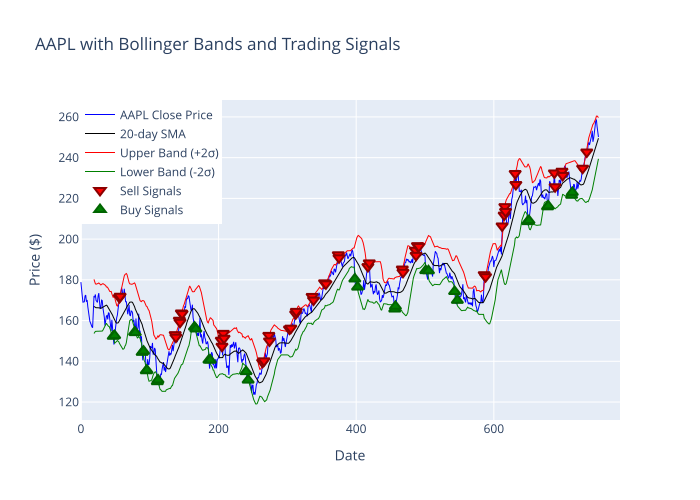

In [ ]:

fig = go.Figure()

# Add close price
fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Close'],
    name='AAPL Close Price',
    line=dict(color='blue', width=1)
))

# Add Bollinger Bands
fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Middle_Band'],
    name='20-day SMA',
    line=dict(color='black', width=1)
))

fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Upper_Band'],
    name='Upper Band (+2σ)',
    line=dict(color='red', width=1)
))

fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Lower_Band'],
    name='Lower Band (-2σ)',
    line=dict(color='green', width=1)
))

# Add signals as markers
# Sell signals (price crossing above upper band)
fig.add_trace(go.Scatter(
    x=sell_signal_dates,
    y=combined_data.loc[sell_signal_dates, 'Close'],
    mode='markers',
    marker=dict(
        size=10,
        color='red',
        symbol='triangle-down',
        line=dict(width=2, color='darkred')
    ),
    name='Sell Signals'
))

# Buy signals (price crossing below lower band)
fig.add_trace(go.Scatter(
    x=buy_signal_dates,
    y=combined_data.loc[buy_signal_dates, 'Close'],
    mode='markers',
    marker=dict(
        size=10,
        color='green',
        symbol='triangle-up',
        line=dict(width=2, color='darkgreen')
    ),
    name='Buy Signals'
))

# Update layout
fig.update_layout(
    title='AAPL with Bollinger Bands and Trading Signals',
    xaxis_title='Date',
    yaxis_title='Price ($)',
    legend=dict(x=0, y=1),
    hovermode='x unified'
)

# Show the figure
fig.show()

***Step 5: Create candlestick chart with same signals***

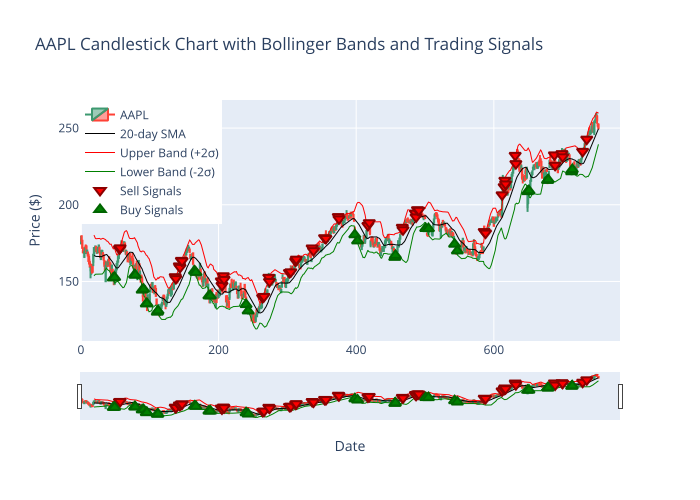

In [ ]:

candlestick_fig = go.Figure()

# Add candlestick chart
candlestick_fig.add_trace(go.Candlestick(
    x=data.index,
    open=data['Open'],
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    name='AAPL'
))

# Add Bollinger Bands
candlestick_fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Middle_Band'],
    name='20-day SMA',
    line=dict(color='black', width=1)
))

candlestick_fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Upper_Band'],
    name='Upper Band (+2σ)',
    line=dict(color='red', width=1)
))

candlestick_fig.add_trace(go.Scatter(
    x=combined_data.index,
    y=combined_data['Lower_Band'],
    name='Lower Band (-2σ)',
    line=dict(color='green', width=1)
))

# Add signals as markers
# Sell signals (price crossing above upper band)
candlestick_fig.add_trace(go.Scatter(
    x=sell_signal_dates,
    y=combined_data.loc[sell_signal_dates, 'Close'],
    mode='markers',
    marker=dict(
        size=10,
        color='red',
        symbol='triangle-down',
        line=dict(width=2, color='darkred')
    ),
    name='Sell Signals'
))

# Buy signals (price crossing below lower band)
candlestick_fig.add_trace(go.Scatter(
    x=buy_signal_dates,
    y=combined_data.loc[buy_signal_dates, 'Close'],
    mode='markers',
    marker=dict(
        size=10,
        color='green',
        symbol='triangle-up',
        line=dict(width=2, color='darkgreen')
    ),
    name='Buy Signals'
))

# Update layout
candlestick_fig.update_layout(
    title='AAPL Candlestick Chart with Bollinger Bands and Trading Signals',
    xaxis_title='Date',
    yaxis_title='Price ($)',
    legend=dict(x=0, y=1),
    hovermode='x unified'
)

# Show the candlestick chart
candlestick_fig.show()



***Step 6: Optional - Create a table of the signal details***


In [ ]:
signal_data = []

# Process buy signals
for date in buy_signal_dates:
    signal_data.append({
        'Date': date,
        'Type': 'BUY',
        'Price': combined_data.loc[date, 'Close'],
        'Band_Value': combined_data.loc[date, 'Lower_Band']
    })

# Process sell signals
for date in sell_signal_dates:
    signal_data.append({
        'Date': date,
        'Type': 'SELL',
        'Price': combined_data.loc[date, 'Close'],
        'Band_Value': combined_data.loc[date, 'Upper_Band']
    })

# Create and display the signals DataFrame
if signal_data:
    signals_df = pd.DataFrame(signal_data).sort_values(by='Date')
    print("\nDetailed Trading Signals:")
    print(signals_df)
else:
    print("\nNo signals detected during this period.")


Detailed Trading Signals:
    Date  Type       Price  Band_Value
0     47   BUY  152.262817  152.306702
1     49   BUY  152.617065  148.893568
30    56  SELL  171.294434  171.062115
31    57  SELL  171.934036  172.750943
2     78   BUY  154.299820  155.105796
..   ...   ...         ...         ...
75   700  SELL  231.270996  233.198801
28   713   BUY  221.522446  221.947122
29   714   BUY  222.959290  221.487133
76   729  SELL  234.801834  233.641445
77   735  SELL  242.773071  244.316347

[78 rows x 4 columns]
